# Questão 1. Cálculo dos Refletores.

Por razões práticas, um refletor é, em geral, armazenado como um vetor $v$ e um escalar $\beta$, de forma que $Q_v = I - \beta v v^*$.

## Letra (a):
Mostre que, para $Q_vx = \left\|x\right\| e_1$, temos $v = x - \left\|x\right\|e_1$ e $\beta = \frac 1 {\left\|x\right\|(\left\|x\right\| - x_1)} = \frac {\left\|x\right\| + x_1}{\left\|x\right\|(\left\|x\right\|^2 - x_1^2)} = \frac {\left\|x\right\| + x_1}{\left\|x\right\|\cdot \left\|y\right\|^2}$, onde $y = (x_2,\dots,x_n)$.

$\textit{Demonstração}$: Note que
$$ Q_v x = \left\|x\right\|e_1 \Rightarrow (I - \beta v v^*)x = \left\|x\right\|e_1 \Rightarrow x - \beta v (v^*x) = \left\|x\right\|e_1 \Rightarrow (\beta v^*x)v = x - \left\|x\right\|e_1 $$
Do lado esquerdo da igualdade temos um vetor que é um múltiplo escalar de $v$. $v$ tem direção fixa, mas podemos escolher o módulo que melhor convém, pois o ganho ou perda de módulo pode ser compensado na constante $\beta$:
- Para $v$: $(\beta v^*x)v$, constante $\beta$
- Para $\alpha v$, $(\frac{\beta}{\alpha}v^*x)(\alpha v)$, constante $\frac{\beta}{\alpha}$
Por isso, sem perda de generalidade façamos $\beta v^*x = 1$. Então $v = x - \left\|x\right\|e_1$ e 
$$\beta = \frac{1}{v^*x} = \frac{1}{(x - \left\|x\right\|e_1)^*x} = \frac{1}{\left\|x\right\| ^2 - \left\|x\right\| x_1} = \frac 1 {\left\|x\right\|(\left\|x\right\| - x_1)} = \frac {\left\|x\right\| + x_1}{\left\|x\right\|(\left\|x\right\|^2 - x_1^2)}$$
Como queríamos demonstrar

## Letra (b):
Verifique que, dependendo do sinal de $x_1$, uma das fórmulas acima para $\beta$ não está
sujeita a perda de precisão devido a cancelamento numérico.

Primeiro, note que se $x_1$ for muito grande em módulo, temos que $\left\|x\right\| \approx |x_1|$. Logo, se $x_1 > 0$, a segunda fórmula $\beta = \frac {\left\|x\right\| + x_1}{\left\|x\right\|\cdot \left\|y\right\|^2}$ não está sujeita a perda de precisão (em função de $x_1$), pois no numerador temos a soma de dois números positivos. Já a primeira fórmula $\beta = \frac 1 {\left\|x\right\|(\left\|x\right\| - x_1)}$ pode ter perdas de precisão quando $x_1$ é grande em módulo e positivo, pois o termo $\left\|x\right\| - x_1$ no denominador é próximo de zero.

Entretanto, se $x_1 \leq 0$, a primeira fórmula vira $\beta = \frac {1} {\left\|x\right\|(\left\|x\right\| + |x_1|)}$, que é estável quando $|x_1|$ é grande, e a segunda fórmula vira $\beta = \frac {\left\|x\right\| - |x_1|} {\left\|x\right\| \cdot \left\|y\right\|^2}$, que fica sujeita a perda de precisão quando $|x_1|$ é grande.

## Letra (c):

Escreva uma função `reflector(x)` que, dado um vetor $x$, calcula o vetor $v$ e o escalar
$\beta$ do refletor de Householder $Q$ tal que $Qx = \left\|x\right\| e_1$.

In [6]:
using LinearAlgebra

function e_i(lenght, i)

    # Constrói o i-ésimo vetor da base canônica
    ei = zeros(lenght)
    ei[i] = 1
    return ei 
end

function scalar_b(norm, x1)

    # Calcula o escalar b considerando melhor estabilidade
    if (x1 <= 0)
        b = 1/(norm * (norm - x1))
    else
        b = (norm + x1)/(norm * (norm^2 - x1^2))
    end

    return b
end

function reflector(x)

    # Informações de x
    norm_x = norm(x)
    length_x = length(x)

    # Vetor e1
    e1 = e_i(length_x, 1)

    # Vetor v e escalar b
    v = x - norm_x * e1
    b = scalar_b(norm_x, x[1])

    return v, b
end

reflector (generic function with 1 method)

Código acima com a implementação da função reflector. No item $(b)$, vimos como a forma como $\beta$ é calculado pode estar sujeita a perda de precisão a depender do sinal da primeira coordenada do vetor $x$. Por isso,  o código abaixo faz a mesma coisa que o acima. A diferença é que o código abaixo calcula $\beta$ da forma ruim

In [13]:
function bad_scalar_neg(norm, x1)
    b = (norm + x1)/(norm * (norm^2 - x1^2))
end

function bad_scalar_pos(norm, x1)
    b = 1/(norm * (norm - x1))
end

function bad_reflector(x)

    # Informações de x
    norm_x = norm(x)
    length_x = length(x)

    # Vetor e1
    e1 = e_i(length_x, 1)

    # Vetor v e escalar b
    v = x - norm_x * e1

    if (x[1] > 0)
        b = bad_scalar_pos(norm_x, x[1])
    else
        b = bad_scalar_neg(norm_x, x[1])
    end

    return v, b
end

function teste_bad_reflector()
    print("================ Teste x[2] constante, x[1] crescendo positivamente ================")
    for i in 1:7
        print("\n===---------------===\n")
        print("==== Teste para $(10^i) ====\n")
        x = [10^i, 1]

        v_bad, b_bad = bad_reflector(x)
        v_good, b_good = reflector(x)

        print("b good: ")
        print(b_good)
        print("\nb bad: ")
        print(b_bad)
        print("\nDiferença absoluta: ")
        print(b_bad - b_good)
        print("\ndiferença relativa: ")
        print(2 * (b_bad - b_good)/(b_bad + b_good))
        print("\n")
    end

    print("\n\n================ Teste x[2] constante, x[1] crescendo negativamente ================")
    for i in 1:7
        print("\n===---------------===\n")
        print("==== Teste para $(10^i) ====\n")
        x = [-10^i, 1]

        v_bad, b_bad = bad_reflector(x)
        v_good, b_good = reflector(x)

        print("b good: ")
        print(b_good)
        print("\nb bad: ")
        print(b_bad)
        print("\nDiferença absoluta: ")
        print(b_bad - b_good)
        print("\ndiferença relativa: ")
        print(2 * (b_bad - b_good)/(b_bad + b_good))
        print("\n")
    end
end

teste_bad_reflector()

================ Teste x[2] constante, x[1] crescendo positivamente ================
===---------------===
==== Teste para 10 ====
b good: 1.9950371902099893
b bad: 1.9950371902100024
Diferença absoluta: 1.3100631690576847e-14
diferença relativa: 6.566610264141436e-15

===---------------===
==== Teste para 100 ====
b good: 1.9999500037496878
b bad: 1.9999500037501137
Diferença absoluta: 4.2588155224621005e-13
diferença relativa: 2.1294609937632608e-13

===---------------===
==== Teste para 1000 ====
b good: 1.9999994997675443
b bad: 1.9999994998152573
Diferença absoluta: 4.771294470629073e-11
diferença relativa: 2.3856478319753165e-11

===---------------===
==== Teste para 10000 ====
b good: 1.9999999651976785
b bad: 1.9999999677646736
Diferença absoluta: 2.566995060959698e-9
diferença relativa: 1.2834975519905134e-9

===---------------===
==== Teste para 100000 ====
b good: 2.0000038146545416
b bad: 2.000002233214028
Diferença absoluta: -1.5814405136538312e-6
diferença relativa: -7.90

Para demonstrar a diferença entre os escalares a depender da forma como são calculados e do sinal de $x_{1}$, fizemos o código acima que calcula da forma ruim o escalar e da forma correta para efeito de comparação. Para $x = [n, 1]$, temos que $$b = \frac{1}{\sqrt{n^2 + 1}(\sqrt{n^2 + 1} - n)} = 1 + \sqrt{1 - \frac{1}{n^2 + 1}}$$Que tende a $2$ monotonicamente crescente quando $n \rightarrow \infty$. Para $n = 10.000.000$, $b \approx 1,999999999999$. Enquanto o cálculo de $b$ da forma correta nos dá $1,9999999999999951$, da forma errada temos $1,9884107851851751$, um erro bem expressivo.

Para $x_1 = -n$ muito negativo, temos que $$b = \frac{1}{\sqrt{n^2 + 1}(\sqrt{n^2 + 1} + n)} = 1 - \sqrt{1 - \frac{1}{n^2 + 1}}$$Que tende a $0$ monotonicamente decrescente quando $n \rightarrow \infty$. Para $n = 10.000.000$, $b \approx 4.9999999999999625e-15$. Enquanto o jeito certo de calcular nos dá $b = 4.999999999999961e-15$, da forma errada temos $b = 5.029141902923559e-15$, uma diferença relativa na casa dos $5 *10^{-3}$. A diferença relativa nesse caso é fundamental, pois os betas são muito pequenos. Queremos ver o quão diferente esses betas são na escala de tamanho deles. Imagine um erro de 1cm em alguma medição. Para um ser humano, esse erro é quase desprezível. Agora, para uma formiga esse erro é gigante. Então o erro absoluto pode estar na casa de $10^{-17}$, mas beta está na casa de $10^{-15}$.

Comprovamos assim que a expressão com a qual calculamos $\beta$ influencia diretamente na perda de precisão.

## Letra (d):

Condicionamento. Mostre que a derivada de $v$ em relação a $x$ é $J = I − e_1x^*/\left\|x\right\|$.
Deduza que o número de condicionamento absoluto de $v$ em relação a $x$ é menor ou igual
a 2.

Nós temos que 
$$J = \frac {\partial v}{\partial x} = \frac {\partial}{\partial x}(x) + \frac {\partial}{\partial x}(-e_1\left\|x\right\|) = I -e_1 \frac {\partial}{\partial x}(\left\|x\right\|).$$
A derivada de $\left\|x\right\|$ em relação a uma componente $x_i$ é 
$$\frac {\partial}{\partial x_i}(\sqrt{x^* x}) = \frac 1 2 (x_1^2 + x_2^2 + \cdots + x_n^2)^{-1/2}\cdot 2x_i = \frac {x_i}{\left\|x\right\|}.$$
Assim,
$$\frac {\partial}{\partial x}(\left\|x\right\|) = \frac 1 {\left\|x\right\|} \begin{bmatrix} x_1 & x_2 & \cdots &x_n\end{bmatrix} = \frac {x^*}{\left\|x\right\|}.$$

Como o condicionamento absoluto $\kappa$ de $v$ em relação a $x$ é dado por $\kappa = \left\|J\right\|$, temos que
$$\left\|J\right\| = \left\|I - \frac {e_1 x^*}{\left\|x\right\|}\right\| \leq \left\|I\right\| + \left\|\frac {e_1x^*}{\left\|x\right\|}\right\| = 1 + \frac 1 {\left\|x\right\|}\cdot \left\|\begin{bmatrix} x_1 & x_2 & \cdots & x_n \\ 0 & 0 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & 0\end{bmatrix}\right\|_{2 \to 2}.$$

A norma $\left\|e_1 x^*\right\|_{2 \to 2} = \max_{\left\|u\right\| = 1}\left\|(e_1x^*)u\right\|.$ Note que, se $\left\|u\right\| = 1$,
$$ \left\|(e_1x^*)u\right\| = |x^*u|\cdot \left\|e_1\right\| = |x^*u| \leq \left\|x\right\|,$$
onde a última desigualdade é uma aplicação de Cauchy-Schwarz. Logo, $\left\|e_1x^*\right\| = \left\|x\right\|$, ou seja,
$$J \leq 1 + 1 = 2.$$

## Letra (e):

Estabilidade. Teste sua função com vetores x tanto Float64 quanto Float32, e compare os resultados.
Dica: verifique que a resposta está sendo automaticamente calculada no tipo certo. Se você
passar um vetor Float32 e receber um Float64 de resposta, alguma conta está “promovendo
tipos”. Uma dica é não ter constantes não-inteiras como 1.0, que são interpretadas como Float64.

In [4]:
using LinearAlgebra

function e_i_32(lenght, i)

    # Constrói o i-ésimo vetor da base canônica
    ei = zeros(Float32, lenght)
    ei[i] = 1.0f0
    return ei 
end

function e_i_64(lenght, i)

    # Constrói o i-ésimo vetor da base canônica
    ei = zeros(Float64, lenght)
    ei[i] = 1.0
    return ei 
end

function scalar_b(norm, x1)

    # Calcula o escalar b considerando melhor estabilidade
    if (x1 <= 0)
        b = 1/(norm * (norm - x1))
    else
        b = (norm + x1)/(norm * (norm^2 - x1^2))
    end

    return b
end

function reflector_32(x)

    # Informações de x
    norm_x = norm(x)
    length_x = length(x)

    # Vetor e1
    e1 = e_i_32(length_x, 1)

    # Vetor v e escalar b
    v = x - norm_x * e1
    b = scalar_b(norm_x, x[1])

    return v, b
end

function reflector_64(x)

    # Informações de x
    norm_x = norm(x)
    length_x = length(x)

    # Vetor e1
    e1 = e_i_64(length_x, 1)

    # Vetor v e escalar b
    v = x - norm_x * e1
    b = scalar_b(norm_x, x[1])

    return v, b
end

function teste_vetores()

    println("Diferença entre os vetores calculados com Float32 e Float64")
    valores1 = [-2048, -512, -64, 64, 512, 2048]
    valores2 = [-2048, -512, -64, 64, 512, 2048]

    println("="^50)
    for v1 in valores1
        for v2 in valores2
            x = [v1, v2]
            println("\n\n============= Teste =============")
            print("Vetor utilizado: ")
            println(x)
            x_32 = Float32.(x)
            x_64 = [v1, v2]
        
            v_32, b_32 = reflector_32(x_32)
            v_64, b_64 = reflector_64(x_64)

            norm_diff = norm(v_32 - v_64)
            norm_sum = norm(v_32 + v_64)

            print("Float 32: ")
            print(v_32)
            print("\nFloat 64: ")
            print(v_64)
            print("\nDiferença relativa: ")
            print(2*(norm_diff)/(norm_sum)) 
            print("\nDiferença absoluta: ")
            print(norm_diff)
        end
    end

    print("\n\n")
end

function teste_betas()

    println("Diferença entre os betas calculados com Float32 e Float64")
    valores1 = [-2048, -512, -64, 64, 512, 2048]
    valores2 = [-2048, -512, -64, 64, 512, 2048]

    println("="^50)
    for v1 in valores1
        for v2 in valores2
            x = [v1, v2]
            println("\n\n============= Teste =============")
            print("Vetor utilizado: ")
            println(x)
            x_32 = Float32.(x)
            x_64 = [v1, v2]
        
            v_32, b_32 = reflector_32(x_32)
            v_64, b_64 = reflector_64(x_64)

            print("Float 32: ")
            print(b_32)
            print("\nFloat 64: ")
            print(b_64)
            print("\nDiferença relativa: ")
            print(2*(b_32 - b_64)/(b_32 + b_64)) 
            
        end
    end

    print("\n\n")
end

teste_vetores()
teste_betas()

Diferença entre os vetores calculados com Float32 e Float64


============= Teste =============
Vetor utilizado: [-2048, -2048]
Float 32: Float32[-4944.3096, -2048.0]
Float 64: [-4944.309375740098, -2048.0]
Diferença relativa: 3.6357242791039606e-8
Diferença absoluta: 0.00019457240159681533

============= Teste =============
Vetor utilizado: [-2048, -512]
Float 32: Float32[-4159.0303, -512.0]
Float 64: [-4159.030080316243, -512.0]
Diferença relativa: 4.6086298768318303e-8
Diferença absoluta: 0.00019312125732540153

============= Teste =============
Vetor utilizado: [-2048, -64]
Float 32: Float32[-4097.0, -64.0]
Float 64: [-4096.9997559785115, -64.0]
Diferença relativa: 5.95537534641103e-8
Diferença absoluta: 0.00024402148847002536

============= Teste =============
Vetor utilizado: [-2048, 64]
Float 32: Float32[-4097.0, 64.0]
Float 64: [-4096.9997559785115, 64.0]
Diferença relativa: 5.95537534641103e-8
Diferença absoluta: 0.00024402148847002536

============= Teste =============
Vetor 

No código acima, fizemos testes com vários vetores diferentes em Float32 e Float64. A função reflector foi modificada para que não acontecer promoção de tipos. Verificamos a diferença relativa entre os vetores obtidos, e também pelas constantes betas obtidas. Para os betas, a diferença relativa gira na casa de $10^{-9}$ até $10^{-7}$, um valor relativamente baixo e que reflete os arredondamentos feitos pela limitação do Float32. Para os vetores, a mesma coisa acontece, e a diferença relativa varia de $10^{-11}$ até $10^{-7}$.


## Letra (f):

Escreva uma função calc_beta(v) que calcula β unicamente a partir de v. Repita
os testes Float64 e Float32 usando esta função, e compare os resultados com a função
anterior. Observe que não há muita diferença ao calcular β a partir de x ou apenas de v,
mesmo com x quase alinhado com e1.

In [5]:
function calc_beta(v)
    inner_dot = v' * v
    return 2/(inner_dot[1])
end

println(calc_beta([-2, 4]))

0.1


Os refletores de Householder são da forma $Q_v = I - \frac{2vv^*}{v^*v}$. Com essa igualdade, é possível determinar o valor de $\beta$: $$I - \beta vv^* = I - \frac{2vv^*}{v^*v} \Rightarrow \beta = \frac{2}{v^*v}$$E é exatamente assim que encontramos $\beta$ na função `calc_beta(v)`. Para demonstrar que isso de fato funciona, o seguinte código foi feito:

In [6]:
function teste_calc_beta()
    # testes = [[3, 4], [5, 12], [7, 24], [8, 15], [1000, 12131]]

    for i in 5:10

        for j in 5:10

            teste = [2^i, 2^j]
            println("\n=====================\n")
            println("Teste com o vetor: \n")
            println(teste)
            v, b_refletor = reflector(teste)
            b_calc_beta = calc_beta(v)

            println("b do refletor: ")
            println(b_refletor)
            println("b da função: ")
            println(b_calc_beta)
            println("Diferença entre eles: ")
            println(b_refletor - b_calc_beta)
        end
    
    end
end

teste_calc_beta()



Teste com o vetor: 

[32, 32]
b do refletor: 
0.0016670964660024869
b da função: 
0.0016670964660024878
Diferença entre eles: 
-8.673617379884035e-19


Teste com o vetor: 

[32, 64]
b do refletor: 
0.00035332363171385685
b da função: 
0.00035332363171385696
Diferença entre eles: 
-1.0842021724855044e-19


Teste com o vetor: 

[32, 128]
b do refletor: 
7.5838356020284e-5
b da função: 
7.5838356020284e-5
Diferença entre eles: 
0.0


Teste com o vetor: 

[32, 256]
b do refletor: 
1.715140891401991e-5
b da função: 
1.7151408914019906e-5
Diferença entre eles: 
3.3881317890172014e-21


Teste com o vetor: 

[32, 512]
b do refletor: 
4.05265154325554e-6
b da função: 
4.052651543255541e-6
Diferença entre eles: 
-8.470329472543003e-22


Teste com o vetor: 

[32, 1024]
b do refletor: 
9.834620975281918e-7
b da função: 
9.834620975281918e-7
Diferença entre eles: 
0.0


Teste com o vetor: 

[64, 32]
b do refletor: 
0.001850026553710854
b da função: 
0.0018500265537108554
Diferença entre eles: 
-1

Na função acima, comparamos o valor de $\beta$ calculado por meio da função calc_beta(v), e o $\beta$ calculado dentro da função reflector($x$). Usamos o vetor $v$ retornado pela reflector para calcular beta na calc_beta, podendo assim fazer um paralelo entre as duas formas de calcular

Todos os testes deram diferença nula ou bem próximo disso, confirmando a corretude de calc_beta.

## Letra (g):


# Questão 2. Forma de Hessenberg

Se você se sentir à vontade, pode definir um tipo de dado para os refletores, e então as funções
desta questão poderiam receber e retornar `Refletores`, ao invés de $v$ e $\beta$ separadamente.

## Letra (a):

$\textbf{Aplicando refletores.}$ Escreva uma função `apply_reflector(v, beta, b)` que calcula $Q_vb$, onde $Q_v = I - \beta v v^*$ é o refletor de Householder dado por $v$ e $\beta$.

In [ ]:
struct Reflector{T, V<:AbstractVector{T}}
    v::V
    beta::T
end

function apply_reflector(Q::Reflector, b::AbstractVector)
    c = dot(Q.v, b)
    b .-= (Q.beta * c) .* Q.v
    return b
end

apply_reflector (generic function with 1 method)

Note que não calculamos explicitamente o refletor $Q_v$, pois a construção da matriz exige custo computacional desnecessário para aplicar a transformação em um vetor $b$. Apenas fazemos a operação

$$b \leftarrow b - (\beta v^* b)v.$$

## Letra (b):

$\textbf{Testes.}$ Verifique que a sua função está correta, aplicando em vetores $x$ de mesma dimensão que $v$, e depois para vetores de dimensões $\textit{maiores}$ do que $v$ (adaptando, se necessário,
sua função para funcionar neste caso). Certifique-se que sua função tem complexidade
$O(n)$, onde $n$ é a dimensão do vetor de entrada.

In [ ]:
function apply_reflector2(Q::Reflector, b::AbstractVector)
    k = length(Q.v)
    n = length(b)
    b_tail = @view b[(n - k + 1):end]

    c = dot(Q.v, b_tail)
    b_tail .-= (Q.beta * c) .* Q.v

    return b
end

function test_apply_reflector()
    println("=== TESTE 1: Mesma Dimensão ===")
    x = [3.0, 4.0, 1.0, 2.0]
    n = length(x)

    v, beta = reflector(x)
    Q = Reflector(v, beta)
    
    x_copy = copy(x)
    apply_reflector2(Q, x_copy)
    
    norm_x = norm(x)
    esperado = [norm_x, 0.0, 0.0, 0.0]
    
    println("x original:     ", x)
    println("Q * x obtido:   ", round.(x_copy, digits=10))
    println("||x|| * e1:     ", round.(esperado, digits=10))
    println("Erro numérico:  ", norm(x_copy - esperado))
    
    
    println("\n=== TESTE 2: Dimensão Maior ===")
    b = [10.0, 20.0, 3.0, 4.0, 1.0, 2.0]
    
    b_copy = copy(b)
    apply_reflector2(Q, b_copy)

    esperado_maior = [10.0, 20.0, norm_x, 0.0, 0.0, 0.0]
    
    println("b original:     ", b)
    println("Q * b obtido:   ", round.(b_copy, digits=10))
    println("Esperado:       ", round.(esperado_maior, digits=10))
    println("Erro numérico:  ", norm(b_copy - esperado_maior))
end

test_apply_reflector()

=== TESTE 1: Mesma Dimensão ===
x original:     [3.0, 4.0, 1.0, 2.0]
Q * x obtido:   [5.4772255751, -0.0, -0.0, -0.0]
||x|| * e1:     [5.4772255751, 0.0, 0.0, 0.0]
Erro numérico:  1.3506446028928519e-15

=== TESTE 2: Dimensão Maior ===
b original:     [10.0, 20.0, 3.0, 4.0, 1.0, 2.0]
Q * b obtido:   [10.0, 20.0, 5.4772255751, -0.0, -0.0, -0.0]
Esperado:       [10.0, 20.0, 5.4772255751, 0.0, 0.0, 0.0]
Erro numérico:  1.3506446028928519e-15


## Letra (c):

Generalize sua função para `apply_reflector(v, beta, A)` que calcula $Q_vA$ para uma
matriz $A$ (com no mínimo o mesmo número de linhas do que $v$).

In [10]:
function apply_reflector3(Q::Reflector, A)
    k = length(Q.v)
    n, m = size(A)
    
    A_tail = @view A[(n - k + 1):end, :]
    
    # Calcula o vetor linha wT = v' * A_tail
    wT = Q.v' * A_tail
    
    A_tail .-= (Q.beta .* Q.v) * wT
    
    return A
end

function test_apply_reflector_matrix()
    println("=== TESTE: Refletor em Matriz ===")
    A = [ 3.0  5.0  2.0;
          4.0  2.0  1.0;
          1.0  0.0  4.0;
          2.0  1.0  1.0]
          
    println("Matriz A original:")
    display(A)
    
    x = A[:, 1]
    v, beta = reflector(x)
    Q = Reflector(vec(v), beta)
    
    apply_reflector3(Q, A)
    
    println("\nMatriz Q*A resultante:")
    display(round.(A, digits=10))

    norm_x = norm(x)
    println("\nNorma da primeira coluna original: ", norm_x)
    println("Elemento (1,1) resultante:         ", A[1,1])
end

test_apply_reflector_matrix()

=== TESTE: Refletor em Matriz ===
Matriz A original:


4×3 Matrix{Float64}:
 3.0  5.0  2.0
 4.0  2.0  1.0
 1.0  0.0  4.0
 2.0  1.0  1.0


Matriz Q*A resultante:


4×3 Matrix{Float64}:
  5.47723  4.56435   2.92119
 -0.0      2.70344  -0.487449
 -0.0      0.17586   3.62814
 -0.0      1.35172   0.256275


Norma da primeira coluna original: 5.477225575051661
Elemento (1,1) resultante:         5.477225575051662


## Letra (d):

Escreva uma função `rev_apply_reflector(v, beta, A)` que calcula $AQ_v$ (com $A$ de
dimensões compatíveis).

In [13]:
function rev_apply_reflector(Q::Reflector, A)
    k = length(Q.v)
    n, m = size(A)
    
    A_tail = @view A[:, (m - k + 1):end]
    
    w = A_tail * Q.v
    
    A_tail .-= (Q.beta .* w) * Q.v'
    
    return A
end

function test_rev_apply_reflector()
    println("=== TESTE: Refletor pela Direita ===")
    
    A = [ 1.0  2.0  3.0;
          4.0  5.0  6.0;
          7.0  8.0  9.0 ]
    
    x = [1.0, -2.0, 2.0] 
    v, beta = reflector(x)
    Q = Reflector(vec(v), beta)
    
    A_modificada = copy(A)
    apply_reflector3(Q, A_modificada)     # Q * A
    rev_apply_reflector(Q, A_modificada) # (Q * A) * Q
    
    Q_matriz = I - beta * (v * v')
    A_esperada = Q_matriz * A * Q_matriz
    
    println("Matriz (Q * A * Q) via funções:")
    display(round.(A_modificada, digits=10))
    
    println("\nMatriz (Q * A * Q) via multiplicação:")
    display(round.(A_esperada, digits=10))
    
    println("\nErro numérico: ", norm(A_modificada - A_esperada))
end

test_rev_apply_reflector()

=== TESTE: Refletor pela Direita ===
Matriz (Q * A * Q) via funções:


3×3 Matrix{Float64}:
 1.0  1.33333   4.33333
 2.0  2.33333   9.33333
 3.0  4.66667  11.6667


Matriz (Q * A * Q) via multiplicação:


3×3 Matrix{Float64}:
 1.0  1.33333   4.33333
 2.0  2.33333   9.33333
 3.0  4.66667  11.6667


Erro numérico: 1.8444410139024814e-15


# Questão 3. Exponenciais de Matrizes.

## Letra (a):
$\textbf{Autovetores.}$ Seja $A(w) = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}$. Faça um gráfico os autovalores para $\omega$ variando
de 0 a 1, e também dos autovetores. O que acontece quando $\omega \to 0^+$?

Primeiro, calculamos os autovalores e autovetores de $A(\omega)$ analiticamente. Note que 
$$ \det(A - \lambda I) = 0 \Rightarrow \lambda^2 + \omega^2 = 0 \Rightarrow \lambda = \pm i\omega.$$
Assim, seja $\lambda_1 = i\omega$ e $\lambda_2 = -i\omega$ os autovalores de $A$. Nós temos que
$$(A - \lambda_1 I)v_1 = 0 \Rightarrow \begin{bmatrix} -i\omega & 1 \\ -\omega^2 & -i\omega\end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix}0 \\ 0 \end{bmatrix} \Rightarrow \begin{cases} y = (i\omega)x \\ \omega^2 x = -i\omega y\end{cases} \Rightarrow v_1 = \begin{bmatrix} x \\ i\omega x\end{bmatrix},\,x \in \mathbb C.$$
Similarmente,
$$(A - \lambda_2 I)v_2 = 0 \Rightarrow \begin{bmatrix} i\omega & 1 \\ -\omega^2 & i\omega\end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix}0 \\ 0 \end{bmatrix} \Rightarrow \begin{cases} y = -(i\omega)x \\ \omega^2 x = i\omega y\end{cases} \Rightarrow v_2 = \begin{bmatrix} x \\ -i\omega x\end{bmatrix},\,x \in \mathbb C.$$

## Letra (b):

$\textbf{Condicionamento.}$ Calcule (no computador, mas verifique analiticamente!) uma
decomposição SVD de $A(\omega)$, e deduza o número de condicionamento de $A$. Qual o condi-
cionamento da matriz de autovetores de $A(\omega)$, em função de $\omega$?

Note que
$$A^*A = \begin{bmatrix} 0 & -\omega^2 \\ 1 & 0 \end{bmatrix}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} \omega^4 & 0 \\ 0 & 1\end{bmatrix}.$$
Logo, os autovalores de $A^*A$ são $\sigma_1^2 = 1$ e $\sigma_2^2 = \omega^4$. Assim, os valores singulares de $A$ são $\sigma_1 = 1$ e $\sigma_2 = \omega^2$, e podemos decompor $A$ como
$$A = \begin{bmatrix}1 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 1 & 0 \\ 0 & \omega^2\end{bmatrix}\begin{bmatrix}0 & 1\\ 1 & 0\end{bmatrix}.$$
Assumindo que $0 \leq w \leq 1$, como na letra (a), podemos deduzir que 
$$\kappa(A) = \frac 1 {\omega^2}.$$

A matriz dos autovetores de $A(\omega)$ (dado pela letra (a)) é $M = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega\end{bmatrix}$. Podemos calcular os autovalores de $M^*M$, fazendo
$$M^*M = \begin{bmatrix}1 & -i\omega \\ 1 & i\omega \end{bmatrix} \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega\end{bmatrix} = \begin{bmatrix} 1 + \omega^2 & 1 - \omega^2 \\  1 - \omega^2 & 1 + \omega^2 \end{bmatrix},$$
logo
$$\det(M^*M - \lambda I) = 0 \Rightarrow (1 + \omega^2 - \lambda)^2 = (1 - \omega^2)^2 \Rightarrow \lambda \in \left\{2, 2\omega^2\right\}.$$
Assim, os valores singulares de $M$ são $\sqrt 2$ e $\omega\sqrt 2$, o que implica em 
$$\kappa(M) = \frac 1 {\omega}.$$

In [14]:
function test_svd_omega(omega::Float64)
    println("=== Teste para ω = $omega ===")

    A = [0.0 1.0; -omega^2 0.0]

    F = svd(A)
    println("\nSVD de A(ω):")
    println("U = "); display(round.(F.U, digits=4))
    println("Σ = ", F.S)
    println("V* = "); display(round.(F.Vt, digits=4))
    
    cond_A = cond(A)
    println("\nCondicionamento cond(A): ", cond_A)
    println("Teórico (1/ω²):          ", 1 / omega^2)

    X = [1.0 + 0im   1.0 + 0im; 
         0.0 + omega*im   0.0 - omega*im]

    cond_X = cond(X)
    println("\nCondicionamento cond(X): ", cond_X)
    println("Teórico (1/ω):           ", 1 / omega)
end

test_svd_omega(0.5)
test_svd_omega(0.4321)

=== Teste para ω = 0.5 ===

SVD de A(ω):
U = 


2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

Σ = [1.0, 0.25]
V* = 


2×2 Matrix{Float64}:
  0.0   1.0
 -1.0  -0.0


Condicionamento cond(A): 4.0
Teórico (1/ω²):          4.0

Condicionamento cond(X): 1.9999999999999998
Teórico (1/ω):           2.0
=== Teste para ω = 0.4321 ===

SVD de A(ω):
U = 


2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

Σ = [1.0, 0.18671041]
V* = 


2×2 Matrix{Float64}:
  0.0   1.0
 -1.0  -0.0


Condicionamento cond(A): 5.3558877622302905
Teórico (1/ω²):          5.3558877622302905

Condicionamento cond(X): 2.314279102059708
Teórico (1/ω):           2.3142791020597087


## Letra (c):

$$A(\omega)^2 = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0\end{bmatrix}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0\end{bmatrix} = \begin{bmatrix} -\omega^2 & 0 \\ 0 & -\omega^2\end{bmatrix} = -\omega^2\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = -\omega^2I$$

Sabemos que, para uma matriz $A$ qualquer, $$e^{tA(\omega)} = \sum_{n = 0}^{\infty}\frac{(tA)^n}{n!}$$

Como $A(\omega)^2 = -\omega^2I$, então $A(\omega)^3 = -\omega^2 A(\omega)$, e $A(\omega)^4 = \omega^4I$. Então, $A(\omega)^{2n} = (-1)^n\omega^{2n}I$, e $A(\omega)^{2n + 1} = (-1)^n\omega^{2n}A(\omega)$ $\textbf{Eq(1)}$. Desse modo, podemos separar o somatório nos índices pares e nos índices ímpares, pois nos pares temos a matriz $I$ identidade, e nos ímpares a matriz $A(\omega)$:

$$\sum_{n=0}^{\infty}\frac{(tA)^n}{n!} = \sum_{n = 0}^{\infty}\frac{(tA)^{2n+1}}{(2n+1)!} + \sum_{n = 0}^{\infty}\frac{(tA)^{2n}}{(2n)!} = \sum_{n = 0}^{\infty}\frac{t^{2n + 1}}{(2n+1)!}(-1)^n\omega^{2n}A(\omega) + \sum_{n = 0}^{\infty}\frac{t^{2n}}{(2n)!}(-1)^n\omega^{2n}I$$

Acima apenas dividimos o somatório nos índices pares e ímpares, e substituímos $A(\omega)^n$ pelo resultado da $\textbf{Eq(1)}$. Então, 

$$\sum_{n = 0}^{\infty}\frac{t^{2n + 1}}{(2n+1)!}(-1)^n\omega^{2n}A(\omega) + \sum_{n = 0}^{\infty}\frac{t^{2n}}{(2n)!}(-1)^n\omega^{2n}I = \frac{A(\omega)}{\omega}\sum_{n = 0}^{\infty}\frac{(-1)^n(t\omega)^{2n + 1}}{(2n + 1)!} + I\sum_{n = 0}^{\infty}\frac{(-1)^n(t\omega)^{2n}}{(2n)!}$$

Mas esses somatórios são precisamnte a expansão de Taylor para $sen(\omega t)$ e $cos(\omega t)$. Portanto, 

$$e^{tA(\omega)} = \frac{sen(\omega t)}{\omega}A(\omega) + cos(\omega t)I$$

Como se queria demonstrar.

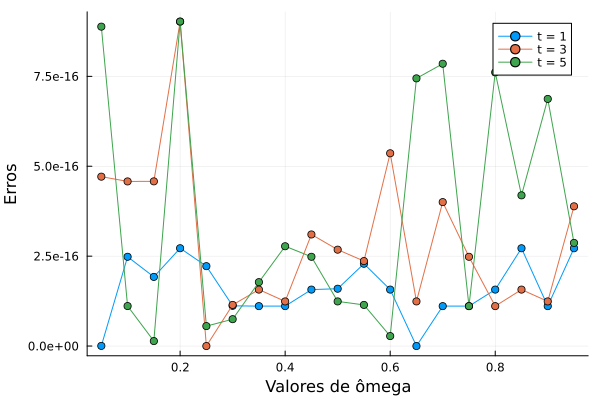

In [3]:
using LinearAlgebra
using Plots
using Printf

function exponential(A, w, t)
    return (sin(w * t)/w) * A + cos(w * t) * I
end

function teste()

    omegas = []
    erros = []

    for i in 1:19

        A = [0 1; (-(i/20)^2) 0]

        # Cálculo da exponencial pelo nativo de Julia, e pela nossa fórmula
        expoA = exponential(A, (i/20), 1)
        expojl = exp(A)
        err = norm(expoA - expojl, 2)

        push!(omegas, (i/20))
        push!(erros, err)
    end

    p = plot(omegas, erros, xlabel="Valores de ômega", ylabel="Erros", marker = :circle, yformatter = val -> @sprintf("%.1e", val), label="t = 1")

    for t in 3:2:5
        erros = []

        for i in 1:19

            A = [0 1; (-(i/20)^2) 0]

            # Cálculo da exponencial pelo nativo de Julia, e pela nossa fórmula
            expoA = exponential(A, (i/20), t)
            expojl = exp(t * A)
            err = norm(expoA - expojl, 2)

            push!(erros, err)
        end

        plot!(omegas, erros, marker=:circle, label="t = $t")
    end

    display(p)
end

teste()

No gráfico acima, fizemos $\omega = i/20$, com $i$ variando de 1 até 19. O gráfico plota o módulo da diferença entre $e^{tA(\omega)}$ com a função nativa de julia, e com a nossa fórmula obtida algebricamente, com vários valores de $t$. Perceba que o erro é muito pequeno, pois de fato as matrizes são iguais salvo erros numéricos obtidos no cálculo delas. Para $0 < \omega < 1$, não há nenhum padrão de crescimento ou decrescimento aparente. O que percebemos é que, para $t$ menor, o módulo é menos no geral, enquanto para $t$ maiores, o gráfico parece mais raivoso e com módulo maior, embora ainda muito pequeno.

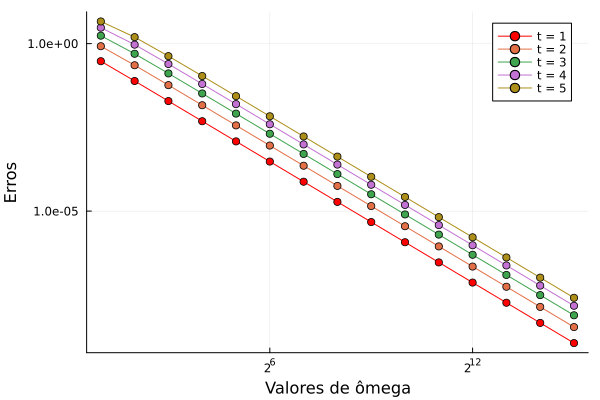

In [9]:
function teste_convergencia()
    
    omegas = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
    erros = []

    # Exponencial da matriz A(0)
    # | 1 1 |
    # | 0 1 |
    expozero = [1 1; 0 1] 

    for i in 1:15
        # omega é igual a n, n que tende a zero
        n = 1/(2^i)
        A = [0 1; -n^2 0]

        # Cálculo da exponencial pelo nativo de Julia, e pela nossa fórmula
        expoA = exponential(A, n, 1)
        err = norm(expoA - expozero, 2)

        # Registra os erros
        push!(erros, err)
    end

    p = plot(omegas, erros, xlabel="Valores de ômega", ylabel="Erros", color =:red, marker = :circle, yscale = :log10, yformatter = val -> @sprintf("%.1e", val), xscale=:log2, label="t = 1")

    for t in 2:5
    
        erros = []

        # Exponencial da matriz tA(0)
        # | 1 t |
        # | 0 1 |
        expozero = [1 t; 0 1] 

        for i in 1:15
            # omega é igual a n, n que tende a zero
            n = 1/(2^i)
            A = [0 1; -n^2 0]

            # Cálculo da exponencial pelo nativo de Julia, e pela nossa fórmula
            expoA = exponential(A, n, t)
            err = norm(expoA - expozero, 2)

            # Registra os erros
            push!(erros, err)
        end

        plot!(omegas, erros, marker = :circle, label="t = $t")
    end

    display(p)

end

teste_convergencia()

Como a matriz $A(0)$ é nilpotente, segue que $A(0)^n = 0$ para qualquer $n \ge 2$. Então

$$e^{tA(0)} = \sum_{n = 0}^{\infty}\frac{(tA(0))^n}{n!} = I + tA(0) = \begin{bmatrix} 1 & t \\ 0 & 1\end{bmatrix}$$

Por isso, o código acima pegou alguns valores de t, e fez $\omega = \frac{1}{2^n}$ para $n = 1, 2, ..., 15$, ou seja, $\omega \rightarrow 0$. O gráfico acima foi bem claro: A norma da diferença entre $e^{tA(0)}$ calculada algebricamente e calculada por nossa fórmula tende a zero, demonstrando a continuidade no ponto $0$. Perceba que todas os gráficos mostram decrescimento muito semelhantes, mas quando $t$ é maior, a linha é "mais alta". O motivo se dá, principalmente por que o condiconamento da matriz cresce quando $t$ também cresce. 

Obs: Os valores de ômega no eixo x não são os valores de ômega exatamente. Afinal, não faria sentido dizer que estou fazendo $\omega \rightarrow 0$ enquanto no gráfico vemos $\omega = 2^{6}, 2^{12}$. Na verdade, $\omega = \frac{1}{2^6}$, $\frac{1}{2^{12}}$. Por isso, quando x aumenta no gráfico, na verdade ômega está tendendo para zero.